In [13]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

import inspect

sp.init_printing("mathjax")

# Finding the functions needed for RK4 simulation

In [14]:
Rcm, rcm, I1, I2, m1, m2, l, g, t = sp.symbols("R_{cm} r_{cm} I_1 I_2 m_1 m_2 l g t")

theta = sp.Function("\\theta")(t)
phi = sp.Function("\\phi")(t)

theta_d = sp.diff(theta, t)
phi_d = sp.diff(phi, t)

all_variables = (theta, theta_d, phi, phi_d, Rcm, rcm, I1, I2, m1, m2, l, g)

Defining the Lagrangian

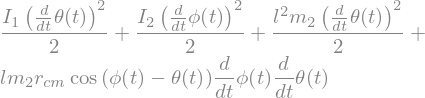

In [15]:
T1 = sp.Rational(1, 2)*I1*theta_d**2
T2 = sp.Rational(1, 2)*m2*l**2*theta_d**2 + sp.Rational(1, 2)*I2*phi_d**2 + m2*l*rcm*theta_d*phi_d*sp.cos(phi-theta)
T = T1 + T2
T_func = sp.lambdify(all_variables, T, "numpy")

V1 = -m1*g*Rcm*sp.cos(theta)
V2 = -m2*g*(l*sp.cos(theta) + rcm*sp.cos(phi))
V = V1 + V2
V_func = sp.lambdify(all_variables, V, "numpy")

L = T - V
T

Finding the equations of motion for $\phi$ and $\theta$

In [16]:
eq_motion_theta = sp.Equality(
    sp.diff(L, theta),
    sp.diff(
        sp.diff(L, theta_d),
        t
    )
)

eq_motion_phi = sp.Equality(
    sp.diff(L, phi),
    sp.diff(
        sp.diff(L, phi_d),
        t
    )
)

Solving for the second derivatives of $\phi$ and $\theta$ in terms of the other variables

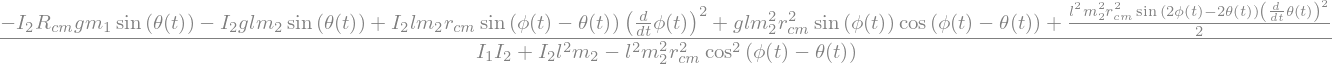

In [17]:
theta_dd = sp.solve(eq_motion_theta, sp.diff(theta_d, t))[0]
phi_dd = sp.solve(eq_motion_phi, sp.diff(phi_d, t))[0]


theta_dd_s = theta_dd.subs(phi_d.diff(t), phi_dd)
phi_dd_s = phi_dd.subs(theta_d.diff(t), theta_dd)

# equations for the second derivative of theta and phi as a function of theta, phi, and their derivatives
theta_dd_s = sp.solve(theta_dd_s - theta_d.diff(t), theta_d.diff(t))[0].simplify()
phi_dd_s = sp.solve(phi_dd_s - phi_d.diff(t), phi_d.diff(t))[0].simplify()

theta_dd_s

Compiling the above expressions into python functions which are quick to compute

In [18]:
tdd = sp.lambdify(all_variables, theta_dd_s, "numpy")
pdd = sp.lambdify(all_variables, phi_dd_s, "numpy")

inspect.getsource(tdd).replace("_lambdifygenerated", "tdd")

'def tdd(_Dummy_92, _Dummy_90, _Dummy_93, _Dummy_91, Dummy_95, Dummy_94, I_1, I_2, m_1, m_2, l, g):\n    return (-1/2*_Dummy_90**2*Dummy_94**2*l**2*m_2**2*sin(2*_Dummy_92 - 2*_Dummy_93) - _Dummy_91**2*Dummy_94*I_2*l*m_2*sin(_Dummy_92 - _Dummy_93) + Dummy_94**2*g*l*m_2**2*sin(_Dummy_93)*cos(_Dummy_92 - _Dummy_93) - Dummy_95*I_2*g*m_1*sin(_Dummy_92) - I_2*g*l*m_2*sin(_Dummy_92))/(-Dummy_94**2*l**2*m_2**2*cos(_Dummy_92 - _Dummy_93)**2 + I_1*I_2 + I_2*l**2*m_2)\n'

# RK4 Simulation

Setting up

In [19]:
# Pendulum parameters, I'll say this one has two bars of uniform mass
Rcm_sim=0.5; rcm_sim=0.5
m1_sim=1; m2_sim=1
l_sim=1; l2_sim=1
g_sim=9.81
I1_sim=1/3*m1_sim*l_sim**2; I2_sim=1/3*m2_sim*(l2_sim)**2

# initial condition
y = np.array([np.pi/10, 0, 0, 0])

# function relating y to y'
def f(y, t):
    return np.array([
        y[1],
        tdd(y[0], y[1], y[2], y[3], Rcm_sim, rcm_sim, I1_sim, I2_sim, m1_sim, m2_sim, l_sim, g_sim),
        y[3],
        pdd(y[0], y[1], y[2], y[3], Rcm_sim, rcm_sim, I1_sim, I2_sim, m1_sim, m2_sim, l_sim, g_sim)
    ])

# time step between simulation frames
h = 0.01
sim_time = 10

# current time in the simulation
t = 0

print(I1_sim, I2_sim)

0.3333333333333333 0.3333333333333333


Performing the simulation

In [20]:
past_positions = np.array(y)

for i in range(int(sim_time/h)):
    k1 = h*f(y, t)
    k2 = h*f(y + k1/2, t + h/2)
    k3 = h*f(y + k2/2, t + h/2)
    k4 = h*f(y + k3, t + h)

    y = y + k1/6 + k2/3 + k3/3 + k4/6

    past_positions = np.vstack([past_positions, y])

Getting the positions of the ends of the arms. Note: I'm now assuming the arms are a solid bar.

In [21]:
theta_sim = past_positions[:, 0]
phi_sim = past_positions[:, 2]

data_rate = 30 #the rate at which (simulated) data is recorded
indices_to_keep = np.linspace(0, len(theta_sim)-1, sim_time*data_rate, dtype=int)
theta_sim_data = theta_sim[indices_to_keep]
phi_sim_data = phi_sim[indices_to_keep]

# simulating the position measurements we would get, including uncertainties
standard_error = 0.0
x1_sim_err = np.random.normal(0, standard_error, len(theta_sim_data))
y1_sim_err = np.random.normal(0, standard_error, len(theta_sim_data))
x2_sim_err = np.random.normal(0, standard_error, len(theta_sim_data))
y2_sim_err = np.random.normal(0, standard_error, len(theta_sim_data))

x1_sim = l_sim*np.sin(theta_sim_data) + x1_sim_err
y1_sim = -l_sim*np.cos(theta_sim_data) + y1_sim_err

phi_sim = past_positions[:, 2]
phi_d_sim = past_positions[:, 3]
x2_sim = x1_sim + l2_sim*np.sin(phi_sim_data) + x2_sim_err
y2_sim = y1_sim - l2_sim*np.cos(phi_sim_data) + y2_sim_err

print("initial condition recorded: " + str(past_positions[0, :]))

initial condition recorded: [0.31415927 0.         0.         0.        ]


In [22]:
data = np.vstack([
    np.arange(0, sim_time, 1/data_rate),
    x1_sim,
    y1_sim,
    np.full(len(x1_sim), 0.1),
    np.full(len(x1_sim), 0.1),
    x2_sim,
    y2_sim,
    np.full(len(x2_sim), 0.1),
    np.full(len(x2_sim), 0.1)
]).transpose()

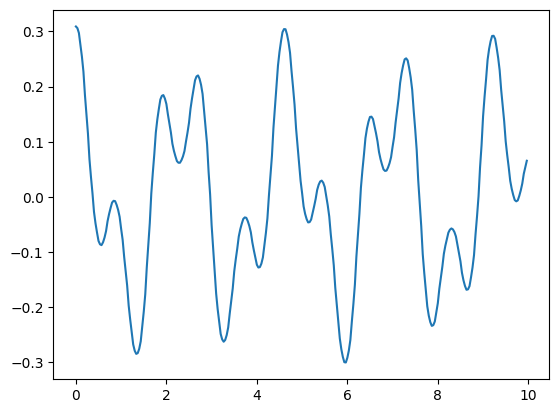

In [23]:
plt.plot(data[:, 0], data[:, 1])

In [24]:
data

array([[ 0.        ,  0.30901699, -0.95105652, ..., -1.95105652,
         0.1       ,  0.1       ],
       [ 0.03333333,  0.30604731, -0.95201631, ..., -1.9520064 ,
         0.1       ,  0.1       ],
       [ 0.06666667,  0.29716067, -0.95482749, ..., -1.95467046,
         0.1       ,  0.1       ],
       ...,
       [ 9.9       ,  0.04192725, -0.99912067, ..., -1.99910257,
         0.1       ,  0.1       ],
       [ 9.93333333,  0.05395064, -0.9985436 , ..., -1.99508427,
         0.1       ,  0.1       ],
       [ 9.96666667,  0.06553311, -0.9978504 , ..., -1.98211566,
         0.1       ,  0.1       ]])